**Install the SHAP and TensorFlow libraries required for interpreting the Deep Neural Network model.**

In [ ]:
!pip install shap tensorflow

**Import the required libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras.models import load_model

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Load the feature dataset**

In [ ]:
df = pd.read_csv("/content/master_features.csv")

print(df.shape)
df.head()

(756, 2055)


,Label,MolecularWeight,LogP,HDonors,HAcceptors,TPSA,RotatableBonds,FP_0,FP_1,FP_2,...,FP_2038,FP_2039,FP_2040,FP_2041,FP_2042,FP_2043,FP_2044,FP_2045,FP_2046,FP_2047
0,1,286.239,1.59282,4,6,115.06,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0,154.253,2.50370,1,1,20.23,1,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0,230.310,5.02060,0,0,0.00,2,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0,108.140,1.70062,1,1,20.23,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,1,313.747,3.18870,0,6,58.40,7,0,1,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


**Separate predictors and target labels**

In [ ]:
X = df.drop("Label", axis=1)
y = df["Label"]

**Split the dataset**

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.4,
    random_state=42,
    stratify=y
)

X_test, X_external, y_test, y_external = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape)
print(X_test.shape)
print(X_external.shape)

(453, 2054)
(151, 2054)
(152, 2054)


**Standardize the feature values**

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
X_external = scaler.transform(X_external)

**Load the trained DNN model**

In [ ]:
model = load_model("/content/drive/MyDrive/Notebook6_Output/DNN_model.keras")

**Select background and sample data**

In [ ]:
background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]
X_sample = X_test[:100]

**Create the SHAP DeepExplainer**

In [ ]:
explainer = shap.DeepExplainer(model, background)

/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(100, 2054))']
  warnings.warn(msg)


**Calculate SHAP values**

In [ ]:
shap_values = explainer.shap_values(X_sample)

print(type(shap_values))
print(np.array(shap_values).shape)

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer
Received: inputs=['Tensor(shape=(200, 2054))']
  warnings.warn(msg)


<class 'numpy.ndarray'>
(100, 2054, 1)


**Prepare SHAP values for visualization**

In [ ]:
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.squeeze(shap_values)

**Generate the SHAP summary plot**

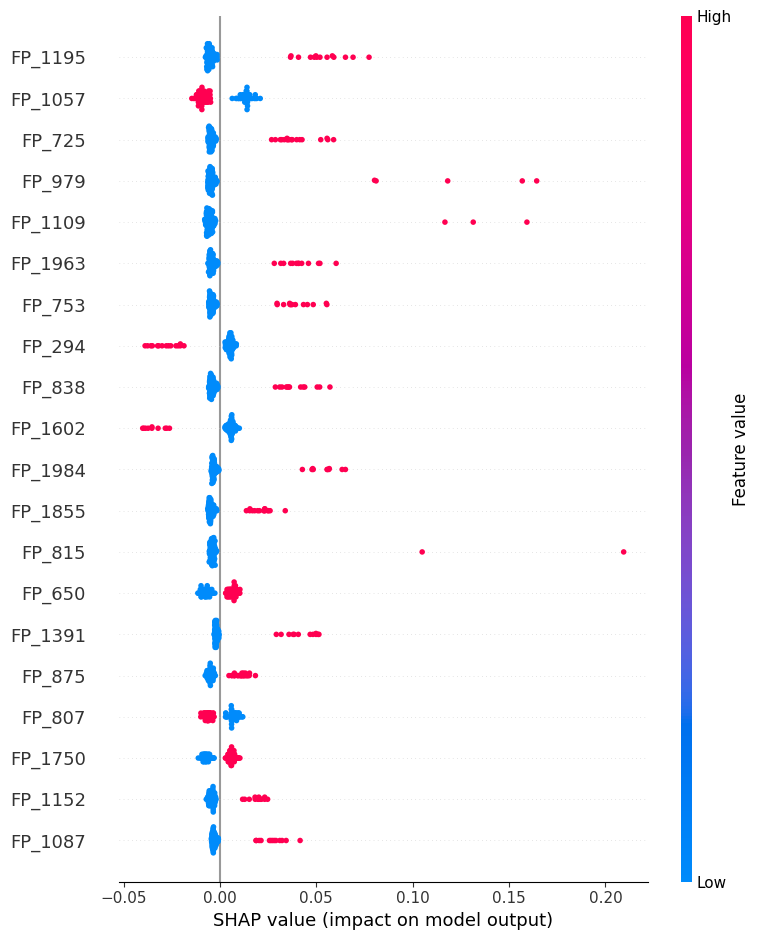

In [ ]:
feature_names = X.columns.tolist()

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    max_display=20
)

**Reload the trained DNN model**

In [ ]:
model = load_model("/content/drive/MyDrive/Notebook6_Output/DNN_model.keras")

**Generate the SHAP bar plot**

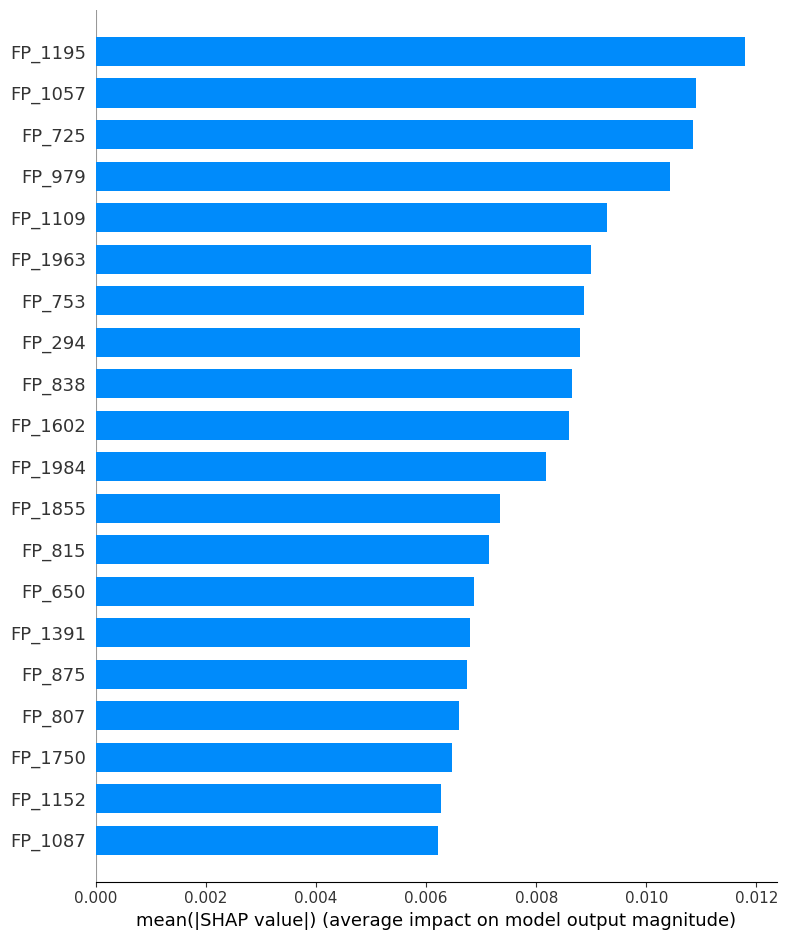

In [ ]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    max_display=20
)

**Create the output directory**

In [ ]:
import os

os.makedirs("/content/drive/MyDrive/Notebook10_Output", exist_ok=True)

**Save the SHAP summary plot**

In [ ]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Notebook10_Output/DNN_SHAP_Summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Summary plot saved successfully!")

Summary plot saved successfully!


**Save the SHAP bar plot**

In [ ]:
plt.figure(figsize=(10,8))

shap.summary_plot(
    shap_values,
    X_sample,
    feature_names=feature_names,
    plot_type="bar",
    show=False
)

plt.savefig(
    "/content/drive/MyDrive/Notebook10_Output/DNN_SHAP_Bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("Bar plot saved successfully!")

Bar plot saved successfully!
